# 03 — Exploratory Data Analysis & Visualization

**Goal of this notebook:** explore the cleaned dataset visually, save chart images to `reports/` for the README, and confirm which relationships are worth carrying into the Power BI dashboard.

**Note:** in every chart below, `savefig()` is called *before* `show()`. `plt.show()` clears the current figure from memory once it's displayed — anything plotted or saved after that point operates on an empty figure. This was the cause of a blank saved image in an earlier version of this notebook.

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/processed/healthcare_data_clean.csv')

sns.set_theme(style='whitegrid', palette='muted')
# Set once at the top — applies to every chart in this notebook

Medical Condition
Cancer          89030.046627
Diabetes        13185.502171
Arthritis        8511.104627
Obesity          7747.113798
Injury           7125.005430
Hypertension     5899.845927
Asthma           4420.304239
Name: Billing Amount, dtype: float64


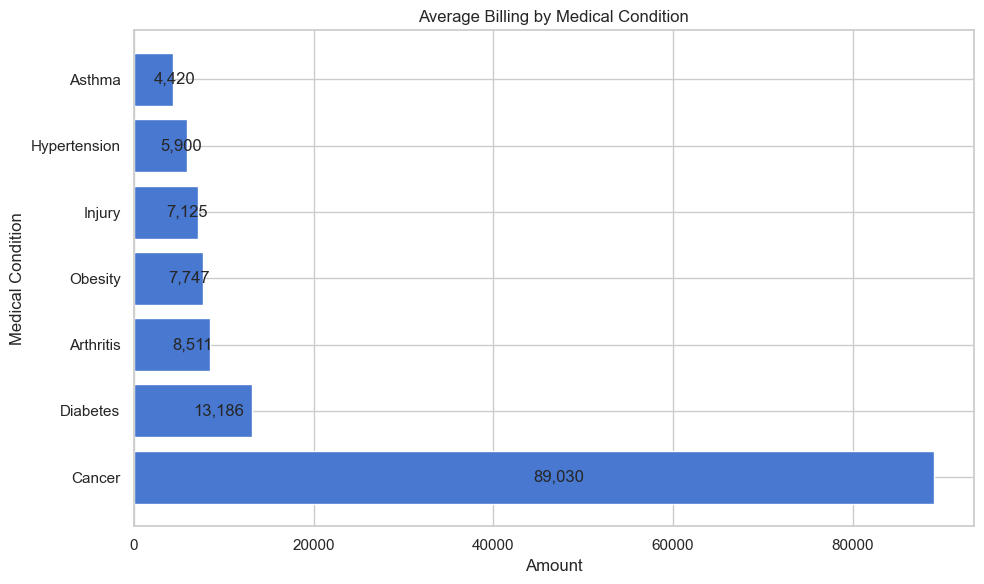

In [10]:
# Average billing by medical condition
# This is the most important chart in the project — Cancer billing is several
# times higher than every other condition, which becomes the central finding
# carried through to the Power BI Cost Analysis page

billing = df.groupby('Medical Condition')['Billing Amount'].mean().sort_values(ascending=False)
print(billing)

plt.figure(figsize=(10, 6))
plt.barh(billing.index, billing.values)
plt.title('Average Billing by Medical Condition', loc='center')
plt.xlabel('Amount')
plt.ylabel('Medical Condition')

# Adding value labels on each bar — note the order of arguments to plt.text()
# is (x, y, text). Since this is a HORIZONTAL bar chart, x = the billing value
# (how far along the bar to place the label) and y = the category position.
for i in range(len(billing)):
    plt.text(billing.values[i] / 2, i, f'{billing.values[i]:,.0f}', va='center')

plt.tight_layout()
plt.savefig('../reports/avg_billing_by_condition.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# Billing by insurance provider
# Checked here first before deciding whether this is worth a dedicated chart —
# see markdown note below for what this revealed
billPaid = df.groupby('Insurance Provider')['Billing Amount'].mean().sort_values(ascending=False)
billPaid

Insurance Provider
Medicare            89023.794487
Cigna               12525.661288
Blue Cross          11334.384717
Aetna                7661.657093
UnitedHealthcare     7611.119551
Name: Billing Amount, dtype: float64

**Note on the result above:** Medicare's average billing looks far higher than the other four providers. This initially looks like an insurance-driven cost story, but cross-referencing with the Medical Condition × Insurance Provider breakdown (built in Power BI, see `reports/FINDINGS.md`) shows this is mostly explained by Medicare's patient population being concentrated in Cancer cases — the same condition that's already the dominant cost driver above. The insurer itself charges nearly the same amount as every other insurer *for the same condition*. This is a good example of a correlation that needed a second chart to confirm before treating it as a real finding.

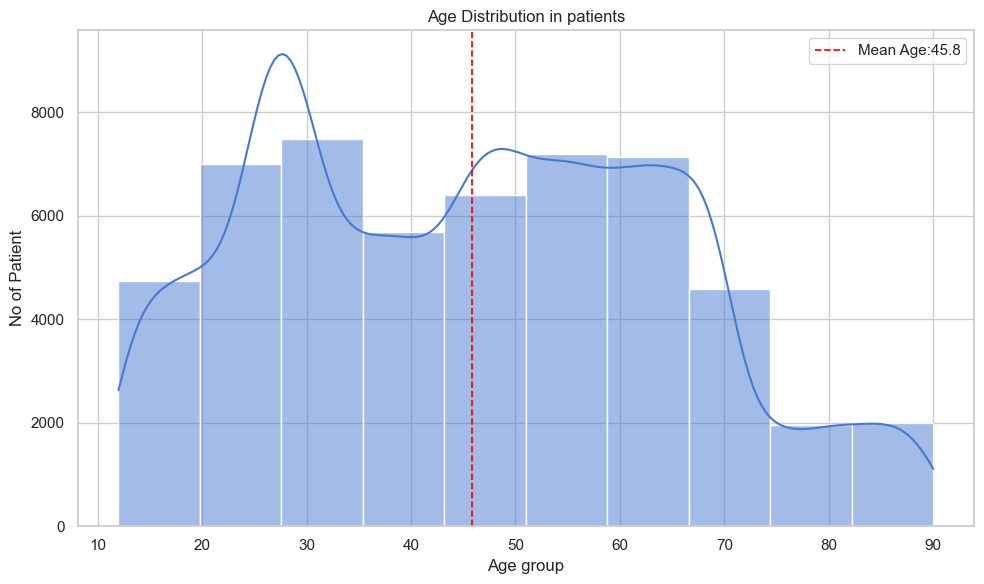

In [11]:
# Age Distribution
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Age', bins=10, kde=True)
plt.xlabel('Age group')
plt.ylabel('No of Patient')
plt.title('Age Distribution in patients')

meanAge = df['Age'].mean()
plt.axvline(meanAge, color='Red', linestyle='--', label=f'Mean Age:{meanAge:.1f}', linewidth=1.25)
plt.legend()
plt.tight_layout()

plt.savefig('../reports/age_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

                  count      mean       std  min  25%  50%   75%   max
Admission Type                                                        
Elective        21839.0  8.853931  4.613608  2.0  6.0  8.0  10.0  21.0
Emergency       17088.0  5.321805  3.774542  1.0  3.0  5.0   6.0  21.0
Urgent          15224.0  9.136364  5.569262  1.0  5.0  7.0  15.0  21.0


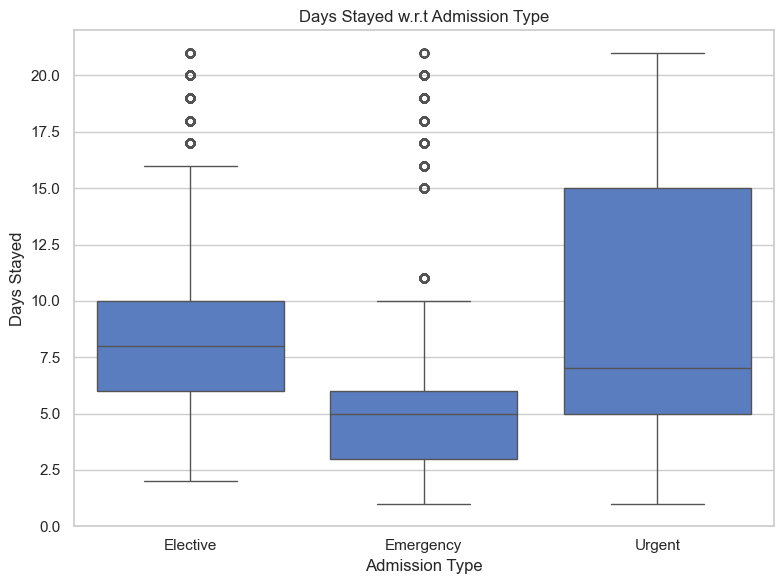

In [13]:
# Days stayed w.r.t Admission Type
print(df.groupby('Admission Type')['Days Stayed'].describe())

plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Admission Type', y='Days Stayed')
plt.title('Days Stayed w.r.t Admission Type')
plt.tight_layout()

plt.savefig('../reports/Days_stayed_by_Admissiontype.png', dpi=150, bbox_inches='tight')
plt.show()

**Note on this chart:** Average days stayed is genuinely different across admission types — Elective (8.85), Emergency (5.32), and Urgent (9.14) — Urgent stays run roughly **72% longer than Emergency** on average. This makes clinical sense: Emergency cases are often stabilized and discharged quickly once the acute issue is handled, while Urgent and Elective cases tend to involve more planned, multi-day treatment. The boxplot also shows Urgent has the widest spread (largest box and longest whisker), meaning Urgent stay length is the least predictable of the three — useful for bed planning, since Urgent patients are the hardest to forecast a discharge date for.

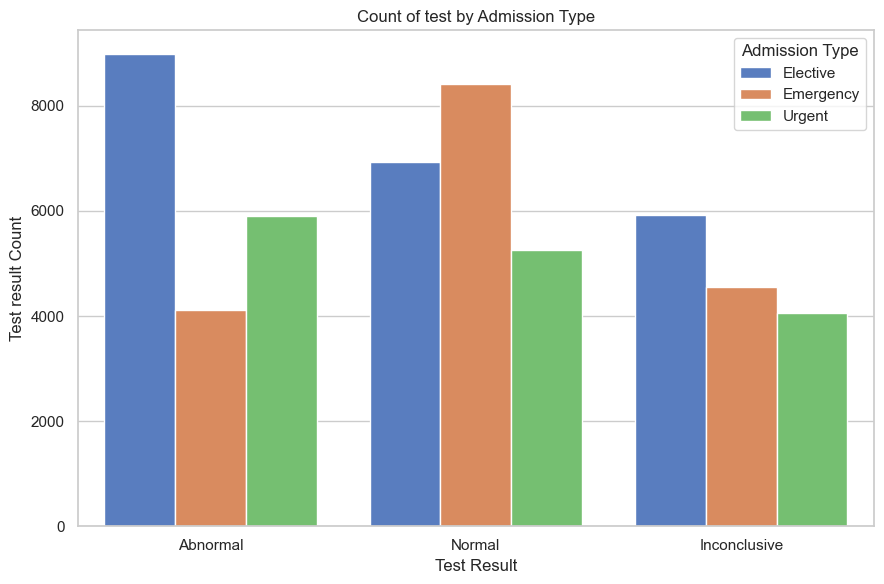

In [14]:
# Test result count by Admission Type
plt.figure(figsize=(9, 6))
sns.countplot(data=df, x='Test Results', hue='Admission Type')
plt.xlabel('Test Result')
plt.ylabel('Test result Count')
plt.title('Count of test by Admission Type')
plt.tight_layout()

plt.savefig('../reports/Total_test_by_Admissiontype.png', dpi=150, bbox_inches='tight')
plt.show()

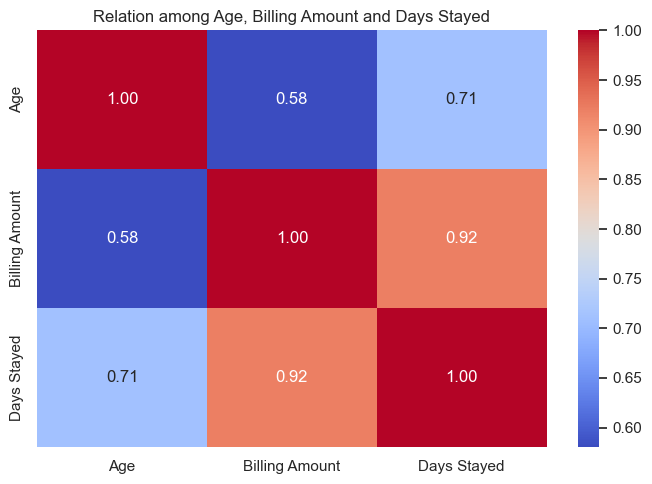

In [15]:
# Correlation heatmap — Age, Billing Amount, Days Stayed
plt.figure(figsize=(7, 5))
corr = df[['Age', 'Billing Amount', 'Days Stayed']].corr()
sns.heatmap(corr, fmt='.2f', annot=True, cmap='coolwarm')
plt.title('Relation among Age, Billing Amount and Days Stayed')
plt.tight_layout()

plt.savefig('../reports/Correlation_among_age_amount_days.png', dpi=150, bbox_inches='tight')
plt.show()

**Note on this heatmap:** unlike the equivalent chart in some other healthcare datasets, these correlations are strong and meaningful, not flat. Billing Amount and Days Stayed correlate at **0.92** — almost a 1-to-1 relationship, meaning cost is driven overwhelmingly by how long a patient stays, not by which condition or insurer is involved in isolation. Age correlates with Days Stayed at **0.71** and with Billing at **0.58** — older patients tend to stay longer and cost more, which lines up with Cancer (the highest-cost, longest-stay condition on the Clinical & Risk page) skewing toward older patients. This is the clearest evidence in the whole EDA that **length of stay, not condition type alone, is the real mechanical driver of cost** — condition determines stay length, and stay length determines cost.

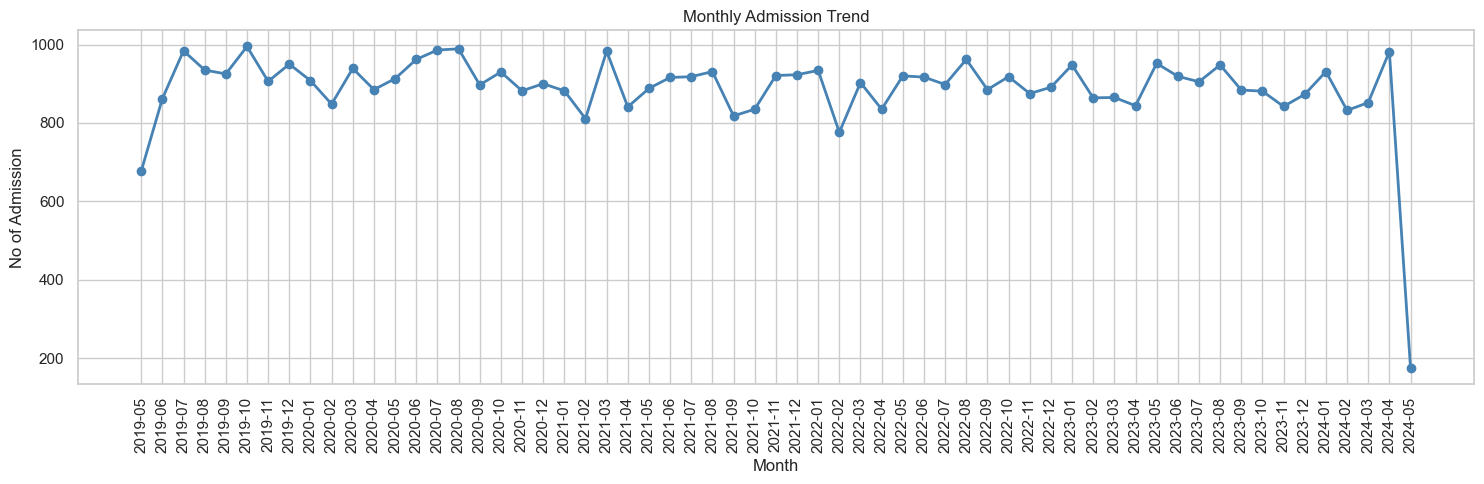

In [16]:
# Monthly Admission trend
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
monthly = df.groupby(df['Date of Admission'].dt.to_period('M')).size()

monthly_index = monthly.index.astype(str)
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(monthly_index, monthly.values, marker='o', color='steelblue', linewidth=2)
plt.xticks(rotation=90, ha='center')
plt.xlabel('Month')
plt.ylabel('No of Admission')
plt.title('Monthly Admission Trend')
plt.tight_layout()

plt.savefig('../reports/Monthly_Admission_Trend.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary — what carried forward into the Power BI dashboard

- Average Billing by Medical Condition → became the core Cost Analysis page finding (Cancer ~7–20x every other condition)
- Insurance Provider billing → kept, but paired with the Medical Condition cross-tab to avoid a misleading conclusion (Medicare's high average is condition-driven, not pricing-driven)
- Days Stayed by Admission Type → genuine difference found (Urgent ~72% longer than Emergency), carried into the Cost Analysis page
- Correlation heatmap → Billing Amount and Days Stayed correlate at 0.92, the strongest relationship in the dataset, confirming length of stay is the real mechanical driver of cost
- Monthly trend → drove the "Peak Month: August" KPI on the Operational Deep-Dive page